In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/real_estate.csv")
df.head()

,id,city,bhk,price_lakh,area_sqft,dist_center_km,amenity_score,segment
0,1,Bangalore,3,110.8,1300,15.1,7.4,Mid-Range
1,2,Nashik,3,189.9,2077,2.6,8.8,Luxury
2,3,Bangalore,1,35.8,628,20.8,4.6,Budget
3,4,Hyderabad,2,75.3,1170,11.2,6.0,Mid-Range
4,5,Bangalore,3,78.8,1040,14.2,6.1,Mid-Range


In [9]:
# adding outliers

np.random.seed(42)
outliers = pd.DataFrame({
    'city':           ['Mumbai', 'Pune', 'Nashik'],
    'bhk':            [2, 3, 1],
    'price_lakh':     [9999, 0.5, 750],  
    'area_sqft':      [500, 9000, 200],  
    'dist_center_km': [2.0, 50.0, 1.5],
    'amenity_score':  [5.0, 3.0, 9.5],
    'segment':        ['Outlier'] * 3
})
df = pd.concat([df, outliers], ignore_index=True)
print(f"Dataset with outliers: {df.shape}")

Dataset with outliers: (162, 8)


In [10]:
features = ['price_lakh', 'area_sqft', 'dist_center_km', 'amenity_score']
X = df[features]

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# DBSCAN 

dbscan = DBSCAN(
    eps = 0.6,   # neighbourhood radius
    min_samples = 4
)

df['cluster'] = dbscan.fit_predict(X_scaled)

In [ ]:
# summary

n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
n_noise    = (df['cluster'] == -1).sum()
print(f"\nClusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")
print(f"\nCluster counts:\n{df['cluster'].value_counts().sort_index()}")


Clusters found : 4
Noise points   : 0

Cluster counts:
cluster
0    150
1      4
2      4
3      4
Name: count, dtype: int64


In [ ]:
# noise points

noise_df = df[df['cluster'] == -1][['city', 'price_lakh', 'area_sqft', 'segment']]
print("\nDetected Outliers / Noise:")
print(noise_df)


Detected Outliers / Noise:
Empty DataFrame
Columns: [city, price_lakh, area_sqft, segment]
Index: []


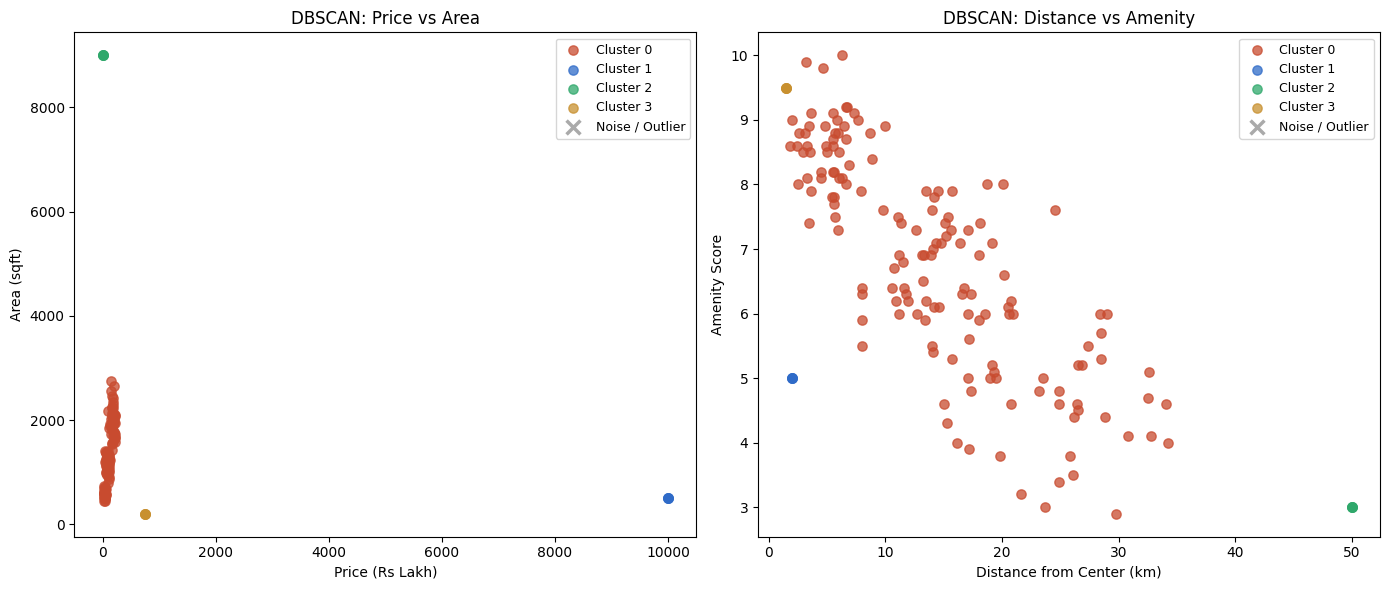

In [17]:
palette = ['#c84b2f', '#2f6bc8', '#2fa86b', '#c8902f', '#9b4fc8']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

noise_mask  = df['cluster'] == -1
normal_mask = ~noise_mask

for c in sorted(df.loc[normal_mask, 'cluster'].unique()):
    mask = df['cluster'] == c
    axes[0].scatter(df.loc[mask, 'price_lakh'], df.loc[mask, 'area_sqft'],
                    c=palette[c % len(palette)], label=f'Cluster {c}',
                    alpha=0.75, s=45, zorder=2)

axes[0].scatter(df.loc[noise_mask, 'price_lakh'], df.loc[noise_mask, 'area_sqft'],
               c='#aaa', marker='x', s=100, linewidths=2.5,
               label='Noise / Outlier', zorder=3)

axes[0].set_xlabel('Price (Rs Lakh)')
axes[0].set_ylabel('Area (sqft)')
axes[0].set_title('DBSCAN: Price vs Area')
axes[0].legend(fontsize=9)


for c in sorted(df.loc[normal_mask, 'cluster'].unique()):
    mask = df['cluster'] == c
    axes[1].scatter(df.loc[mask, 'dist_center_km'], df.loc[mask, 'amenity_score'],
                    c=palette[c % len(palette)], label=f'Cluster {c}',
                    alpha=0.75, s=45, zorder=2)

axes[1].scatter(df.loc[noise_mask, 'dist_center_km'], df.loc[noise_mask, 'amenity_score'],
               c='#aaa', marker='x', s=100, linewidths=2.5,
               label='Noise / Outlier', zorder=3)

axes[1].set_xlabel('Distance from Center (km)')
axes[1].set_ylabel('Amenity Score')
axes[1].set_title('DBSCAN: Distance vs Amenity')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()